In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [35]:
Uber_data= pd.read_csv(r"uber-raw-data-janjune-15_sample.csv")
Uber_data.head(5)

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-02 21:43:00,B02764,237
1,B02682,2015-01-20 19:52:59,B02682,231
2,B02617,2015-03-19 20:26:00,B02617,161
3,B02764,2015-04-10 17:38:00,B02764,107
4,B02764,2015-03-23 07:03:00,B00111,140


In [36]:
type(Uber_data)

pandas.core.frame.DataFrame

Lets Perform data pre-processing / data cleaning !!

In [38]:
Uber_data.shape

(100000, 4)

In [66]:
Duplicate_Row = Uber_data.duplicated().sum()
Duplicate_Row

np.int64(54)

In [84]:

# Remove duplicates and update the original DataFrame
Uber_data.drop_duplicates(keep="first", inplace=True)
display (Uber_data)
Uber_data.to_excel("Uber_data_cleaned.xlsx", index=False)

,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID
0,B02617,2015-05-02 21:43:00,B02764,237
1,B02682,2015-01-20 19:52:59,B02682,231
2,B02617,2015-03-19 20:26:00,B02617,161
3,B02764,2015-04-10 17:38:00,B02764,107
4,B02764,2015-03-23 07:03:00,B00111,140
...,...,...,...,...
99995,B02764,2015-04-13 16:12:00,B02764,234
99996,B02764,2015-03-06 21:32:00,B02764,24
99997,B02598,2015-03-19 19:56:00,B02598,17
99998,B02682,2015-05-02 16:02:00,B02682,68


In [85]:
Duplicate_Row = Uber_data.duplicated().sum()
Duplicate_Row

np.int64(0)

In [88]:
Uber_data.isnull().sum()

Dispatching_base_num       0
Pickup_date                0
Affiliated_base_num     1116
locationID                 0
dtype: int64

In [89]:
Uber_data.dtypes

Dispatching_base_num    object
Pickup_date             object
Affiliated_base_num     object
locationID               int64
dtype: object

In [91]:

import warnings
from warnings import filterwarnings

# Ignore all warnings
filterwarnings("ignore")


pd.to_datetime() converts strings to datetime objects.
errors="coerce" ensures invalid dates become NaT instead of throwing an error.

In [1]:

Uber_data["Pickup_date"] = pd.to_datetime(Uber_data["Pickup_date"], errors="coerce")

display(Uber_data)
Uber_data.dtypes


NameError: name 'pd' is not defined

In [ ]:

# Create a new column for month name
Uber_data["Pickup_month"] = Uber_data["Pickup_date"].dt.month_name()

# Display the DataFrame
display(Uber_data)


,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,Pickup_month
0,B02617,2015-05-02 21:43:00,B02764,237,May
1,B02682,2015-01-20 19:52:59,B02682,231,January
2,B02617,2015-03-19 20:26:00,B02617,161,March
3,B02764,2015-04-10 17:38:00,B02764,107,April
4,B02764,2015-03-23 07:03:00,B00111,140,March
...,...,...,...,...,...
99995,B02764,2015-04-13 16:12:00,B02764,234,April
99996,B02764,2015-03-06 21:32:00,B02764,24,March
99997,B02598,2015-03-19 19:56:00,B02598,17,March
99998,B02682,2015-05-02 16:02:00,B02682,68,May


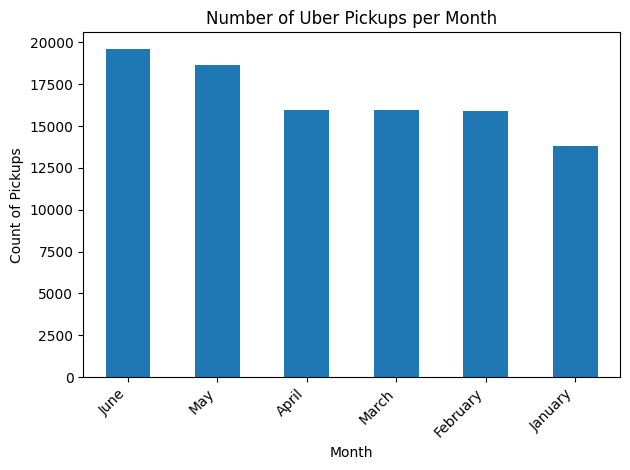

In [ ]:
Uber_data["Pickup_month"].value_counts().plot(kind="bar")

plt.title("Number of Uber Pickups per Month")
plt.xlabel("Month")
plt.ylabel("Count of Pickups")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:

# Extract weekday name, day, hour, and minute
Uber_data["Weekdays"] = Uber_data["Pickup_date"].dt.day_name()   # e.g., Monday, Tuesday
Uber_data["Day"] = Uber_data["Pickup_date"].dt.day              # Day of month (1-31)
Uber_data["hours"] = Uber_data["Pickup_date"].dt.hour           # Hour (0-23)
Uber_data["minutes"] = Uber_data["Pickup_date"].dt.minute       # Minute (0-59)

# Display the updated DataFrame
display(Uber_data)


,Dispatching_base_num,Pickup_date,Affiliated_base_num,locationID,Pickup_month,Day,Weekdays,hours,minutes
0,B02617,2015-05-02 21:43:00,B02764,237,May,2,Saturday,21,43
1,B02682,2015-01-20 19:52:59,B02682,231,January,20,Tuesday,19,52
2,B02617,2015-03-19 20:26:00,B02617,161,March,19,Thursday,20,26
3,B02764,2015-04-10 17:38:00,B02764,107,April,10,Friday,17,38
4,B02764,2015-03-23 07:03:00,B00111,140,March,23,Monday,7,3
...,...,...,...,...,...,...,...,...,...
99995,B02764,2015-04-13 16:12:00,B02764,234,April,13,Monday,16,12
99996,B02764,2015-03-06 21:32:00,B02764,24,March,6,Friday,21,32
99997,B02598,2015-03-19 19:56:00,B02598,17,March,19,Thursday,19,56
99998,B02682,2015-05-02 16:02:00,B02682,68,May,2,Saturday,16,2


In [ ]:
table= pd.crosstab(index= Uber_data["Pickup_month"], columns= Uber_data["Weekdays"])
table
                   

Weekdays,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
Pickup_month,,,,,,,
April,2365,1833,2508,2052,2823,1880,2521
February,2655,1970,2550,2183,2396,2129,2013
January,2508,1353,2745,1651,2378,1444,1740
June,2793,2848,3037,2485,2767,3187,2503
March,2465,2115,2522,2379,2093,2388,2007
May,3262,1865,3519,2944,2627,2115,2328


<Axes: xlabel='Pickup_month'>

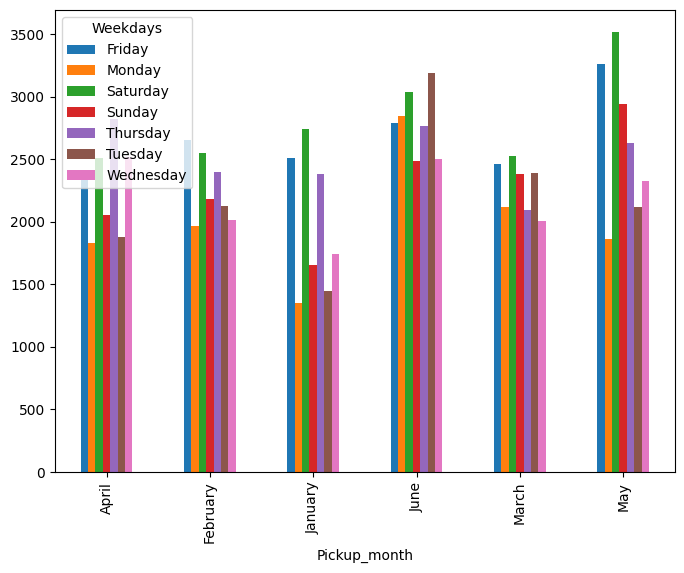

In [ ]:
table.plot(kind="bar", figsize=(8,6))